In [1]:
# import libraries 
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import TensorBoard
# ignore warnings
import warnings
warnings.filterwarnings('ignore')
# ignore warning in the output
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

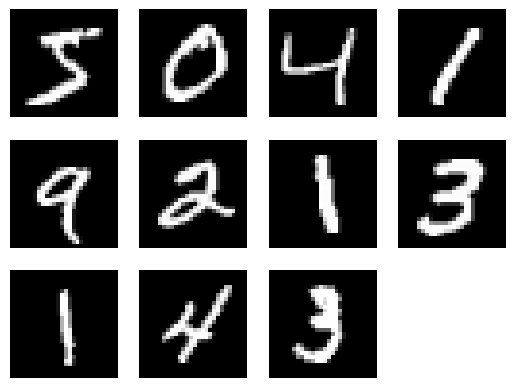

In [5]:
# load the mnist dataset
mist = tf.keras.datasets.mnist
# split the dataset into training and testing sets
(x_train, y_train), (x_test, y_test) = mist.load_data()
# normalize the data
x_train = x_train / 255.0
x_test = x_test / 255.0
# plot the first 11 image in the training set
import matplotlib.pyplot as plt
for i in range(11):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()



In [12]:
# create the model using convolutional layers, max pooling layers, and a dropout layer
# Reshape the data to include channel dimension


model = Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9949 - loss: 0.0169
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - accuracy: 0.9961 - loss: 0.0127
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9962 - loss: 0.0120
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9968 - loss: 0.0100
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9971 - loss: 0.0089
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9916 - loss: 0.0323
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9972 - loss: 0.0095 - val_accuracy: 0.9928 - val_loss: 0.0319
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9975 - loss: 0.0074 - val_accuracy: 0.9920 - val_loss: 0.0362
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9976 - loss: 0.0075 - val_accuracy: 0.9923 - val_loss: 0.0356
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9981 - loss: 0.006

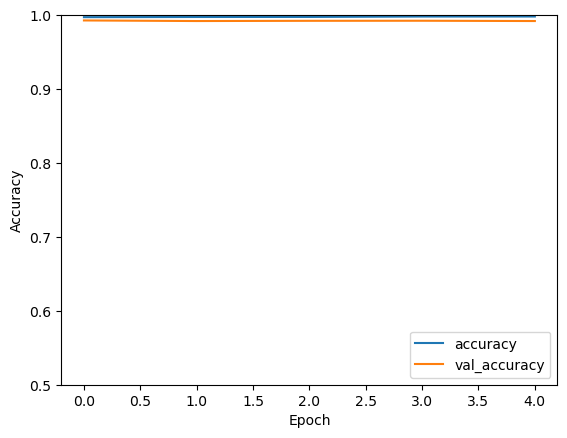

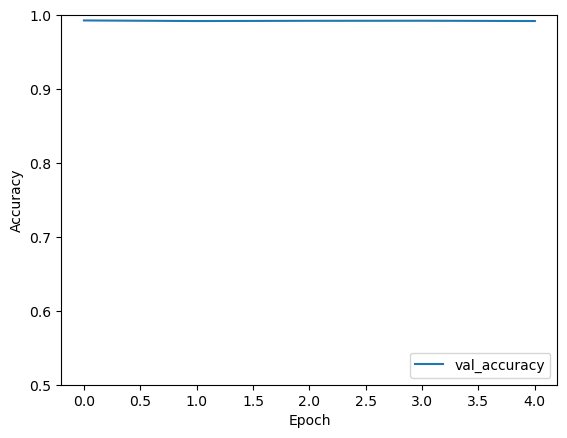

In [14]:
# compile the model 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# train the model 
model.fit(x_train, y_train, epochs=5)
# evaluate the model 
model.evaluate(x_test, y_test)
# plot the training and validation accuracy and loss at each spech
# compile the model 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# train the model 
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))
# evaluate the model 
model.evaluate(x_test, y_test)
# plot the training and validation accuracy and loss at each spech
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()

In [ ]:
# let's create a call back function of tensorboard

tensorboard = TensorBoard(log_dir='logs')
# train the model 
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), callbacks=[tensorboard])

In [ ]:
# activate inline tensorboard extension 
%load_ext tensorboard
# run the tensorboard of recent logs here
%tensorboard --logdir logs